<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insurance risk scoring — fairness case study

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 17 — Fairness is a design choice — make it, justify it, monitor it  
**Rows:** 240  ·  **Source file:** `insurance_telematics_drivers.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/insurance_telematics_drivers.csv"
LOCAL = "insurance_telematics_drivers.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (240, 10)


,driver_id,age,age_cluster,gender,license_age_years,annual_km_profile,persona,base_risk_score,home_region,claim_history_3y
0,DR0001,31,Early career,M,13,7044,Weekend distance driver,14.4,Rennes,0
1,DR0002,62,Senior,F,7,19065,Urban hustler,10.0,Paris,2
2,DR0003,31,Early career,F,8,11908,Cautious commuter,11.9,Toulouse,0
3,DR0004,46,Experienced,M,10,17515,Cautious commuter,10.0,Lille,0
4,DR0005,33,Early career,F,15,10446,Young explorer,33.0,Rennes,0


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
driver_id                str
age                    int64
age_cluster              str
gender                   str
license_age_years      int64
annual_km_profile      int64
persona                  str
base_risk_score      float64
home_region              str
claim_history_3y       int64

No missing values.


---
## Problem 1 · Easy — describe

How does base_risk_score differ by gender and by age cluster? Which factor separates risk more? (Just measure.)

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Drivers: {len(df)}")
print("\nBy persona:\n", df["persona"].value_counts())
print("\nBase risk score:\n", df["base_risk_score"].describe().round(2))
print("\nClaims in last 3 years:\n", df["claim_history_3y"].value_counts().sort_index())

Drivers: 240

By persona:
 persona
Cautious commuter          56
Urban hustler              53
Family traveller           51
Business road warrior      30
Weekend distance driver    25
Young explorer             25
Name: count, dtype: int64

Base risk score:
 count    240.00
mean      16.58
std        7.43
min       10.00
25%       10.00
50%       13.55
75%       21.35
max       38.90
Name: base_risk_score, dtype: float64

Claims in last 3 years:
 claim_history_3y
0    216
1      6
2     11
3      7
Name: count, dtype: int64


---
## Problem 2 · Intermediate — build

Which risk factors are LEGITIMATE (behaviour: annual km, claim history, licence age) vs SENSITIVE (gender, age)? Recompute a risk score using only behavioural features — how much does it change the ranking?

*Try it yourself first. The worked solution is below.*

In [4]:
print("Mean risk score by group — check every protected characteristic:")
for col in ["gender","age_cluster","home_region"]:
    print(f"\n-- {col}")
    print(df.groupby(col).agg(n=("driver_id","size"),
                              mean_risk=("base_risk_score","mean"),
                              mean_claims=("claim_history_3y","mean")).round(3))

Mean risk score by group — check every protected characteristic:

-- gender
          n  mean_risk  mean_claims
gender                             
F       107     17.196        0.140
M       133     16.087        0.256

-- age_cluster
               n  mean_risk  mean_claims
age_cluster                             
Early career  60     21.162        0.167
Experienced   59     13.495        0.220
Prime         45     15.731        0.111
Senior        46     10.637        0.304
Young         30     23.883        0.233

-- home_region
              n  mean_risk  mean_claims
home_region                            
Bordeaux     24     14.912        0.208
Lille        31     16.232        0.161
Lyon         27     16.985        0.259
Marseille    21     18.610        0.000
Nantes       18     16.106        0.444
Nice         19     17.811        0.105
Paris        34     16.041        0.118
Rennes       21     17.219        0.667
Strasbourg   13     12.008        0.154
Toulouse     32     1

---
## Problem 3 · Advanced — judge

Choose a fairness criterion (demographic parity vs calibration) for pricing and justify it to a regulator. Note that EU rules restrict gender-based insurance pricing (Test-Achats ruling). Write the responsible-AI impact assessment.

*Try it yourself first. The worked solution is below.*

In [5]:
print("Does the score track actual claims equally well for everyone?")
print("(If it predicts well for one group and badly for another, that is a")
print(" fairness problem even when the average score looks even.)\n")
for g, sub in df.groupby("gender"):
    if len(sub) > 15:
        print(f"  {g:<8} n={len(sub):3d}  corr(score, claims) = "
              f"{sub['base_risk_score'].corr(sub['claim_history_3y']):+.3f}")
print("""
EU context you must state in any insurance model review
  · Test-Achats (CJEU, 2011) barred gender-based pricing in EU insurance
  · Removing the column is NOT enough — proxies (mileage profile, vehicle,
    region) can reconstruct it
  · Under the EU AI Act, insurance pricing for life and health is high-risk
  · n=%d here is far too small for any real deployment decision
""" % len(df))

Does the score track actual claims equally well for everyone?
(If it predicts well for one group and badly for another, that is a
 fairness problem even when the average score looks even.)

  F        n=107  corr(score, claims) = -0.074
  M        n=133  corr(score, claims) = +0.065

EU context you must state in any insurance model review
  · Test-Achats (CJEU, 2011) barred gender-based pricing in EU insurance
  · Removing the column is NOT enough — proxies (mileage profile, vehicle,
    region) can reconstruct it
  · Under the EU AI Act, insurance pricing for life and health is high-risk
  · n=240 here is far too small for any real deployment decision



---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


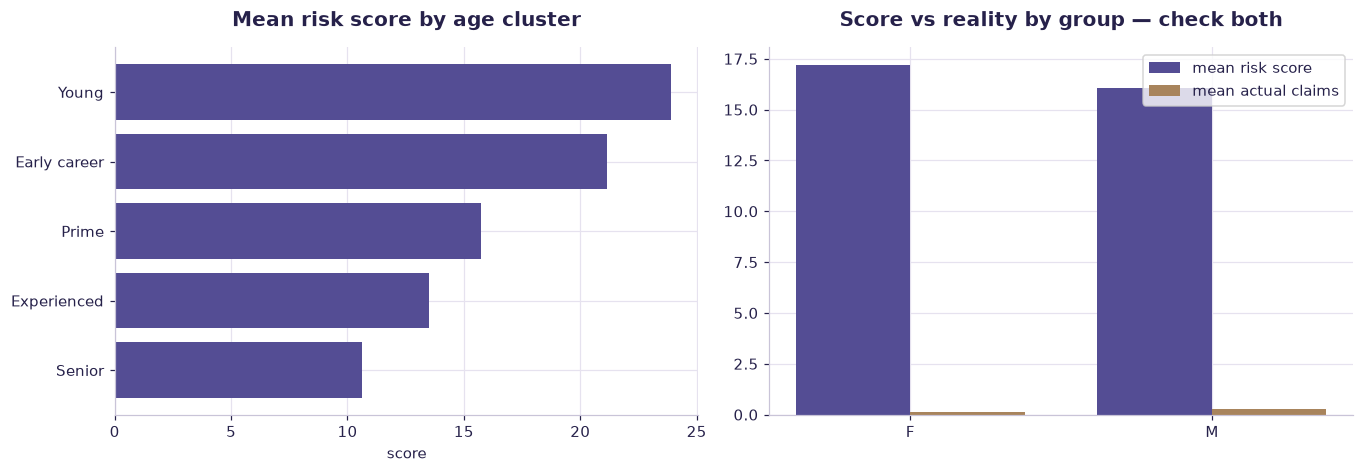

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
g = df.groupby("age_cluster")["base_risk_score"].mean().sort_values()
ax[0].barh(g.index, g.values, color=ACCENT)
ax[0].set_title("Mean risk score by age cluster"); ax[0].set_xlabel("score")

sub = df.groupby("gender").agg(risk=("base_risk_score","mean"), claims=("claim_history_3y","mean"))
x = np.arange(len(sub)); w = .38
ax[1].bar(x - w/2, sub["risk"], w, label="mean risk score", color=ACCENT)
ax[1].bar(x + w/2, sub["claims"], w, label="mean actual claims", color=BUILDER)
ax[1].set_xticks(x); ax[1].set_xticklabels(sub.index)
ax[1].set_title("Score vs reality by group — check both"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Risk by gender is close (M 16.1 vs F 17.2) — small, and legally sensitive to use at all in EU pricing
2. Risk by age is large: Young 23.9 & Early-career 21.2 vs Senior 10.6 — behaviourally plausible but age is a protected axis
3. The exercise: can you get most of the predictive power from BEHAVIOURAL features (km, claims, licence age) alone?
4. Real law: the EU Test-Achats ruling bans gender-based insurance pricing — "accurate" is not the same as "lawful" or "fair"


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Responsible AI impact assessment for one concrete use case.

---
*Applied AI Academy · appliedai.center*
